# Homework 04: Building CNNs for Image Classification

### Due: September 27th at 11:59pm (with 2-hour + 1 minute grace period) and worth 85 points

In this assignment, you will take your first steps into designing and training convolutional neural networks (CNNs) for image classification. Starting from a simple baseline, you will experiment with modifications that reflect the kinds of design choices practitioners face every day. Along the way, you’ll see how architecture, hyperparameters, normalization, pooling strategies, and learning rate schedules can each shape a model’s performance.

The problems are organized to build on each other:

1. **Hyperparameters:** Begin with a baseline CNN and try variations in learning rate, layer width, depth, and dropout.
2. **Batch Normalization:** Add normalization after convolutional layers to stabilize training and speed convergence.
3. **Global Average Pooling:** Replace the flatten-and-dense head with a modern pooling layer, reducing parameters and improving generalization.
4. **ReduceLROnPlateau:** Explore a widely used learning rate scheduler that adapts when validation progress slows.
5. **Very Deep CNN:** Finally, run a VGG-16–style model to observe how deeper networks behave compared to smaller ones.

By the end of this homework, you will have hands-on experience with both classical and modern CNN design strategies, a sense of how different components affect learning, and a toolkit of techniques that will serve you in future image processing projects. 

There are 10 graded questions, worth 8 points each, with 5 points free if you complete all of the graded questions in the homework. 


## 1. Setup and Data Loading


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import os,time,random,kagglehub

import tensorflow as tf
from tensorflow.keras import layers, Input, models, callbacks, regularizers,initializers
from tensorflow.keras.callbacks import Callback,EarlyStopping,ReduceLROnPlateau
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical, load_img, img_to_array
from tensorflow.keras.optimizers import Adam,AdamW
from tensorflow.keras.optimizers.schedules import CosineDecay, ExponentialDecay
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img, img_to_array
from tensorflow.keras.layers import Dense,Input,Dropout,Flatten,MaxPooling2D,Conv2D,SeparableConv2D,GlobalAveragePooling2D,GlobalMaxPooling2D,BatchNormalization

from sklearn.model_selection import train_test_split

# utility code

# -------------------------
# Reproducibility settings
# -------------------------

random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
tf.keras.utils.set_random_seed(random_seed)

def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppresses INFO and WARNING messages

### Utility function to plot learning curves and keep track of all results

- Call `print_results()` to see listing of all results logged so far

In [5]:

def plot_learning_curves(hist, title, verbose=True):
    
    val_losses = hist.history['val_loss']
    min_val_loss = min(val_losses)
    min_val_epoch = val_losses.index(min_val_loss)
    val_acc_at_min_loss = hist.history['val_accuracy'][min_val_epoch]

    epochs = range(1, len(val_losses) + 1)  # epoch numbers starting at 1

    fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

    # --- Loss Plot ---
    axs[0].plot(epochs, hist.history['loss'], label='train loss')
    axs[0].plot(epochs, hist.history['val_loss'], label='val loss')
    axs[0].scatter(min_val_epoch + 1, min_val_loss, color='red', marker='x', s=50, label='min val loss')
    axs[0].set_title(f'{title} - Categorical Cross-Entropy Loss')
    axs[0].set_ylabel('Loss')
    axs[0].legend()
    axs[0].grid(True)

    # --- Accuracy Plot ---
    axs[1].plot(epochs, hist.history['accuracy'], label='train acc')
    axs[1].plot(epochs, hist.history['val_accuracy'], label='val acc')
    axs[1].scatter(min_val_epoch + 1, val_acc_at_min_loss, color='red', marker='x', s=50, label='acc @ min val loss')
    axs[1].set_title(f'{title} - Accuracy')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Accuracy')
    axs[1].legend()
    axs[1].grid(True)
    axs[1].set_ylim(0, 1.05)

    plt.tight_layout()
    plt.show()

    if verbose:
        print(f"Final Training Loss:            {hist.history['loss'][-1]:.4f}")
        print(f"Final Training Accuracy:        {hist.history['accuracy'][-1]:.4f}")
        print(f"Final Validation Loss:          {hist.history['val_loss'][-1]:.4f}")
        print(f"Final Validation Accuracy:      {hist.history['val_accuracy'][-1]:.4f}")
        print(f"Minimum Validation Loss:        {min_val_loss:.4f} (Epoch {min_val_epoch + 1})")
        print(f"Validation Accuracy @ Min Loss: {val_acc_at_min_loss:.4f}")

    results[title] = (val_acc_at_min_loss,min_val_epoch + 1)

results = {}

def print_results():
    for title, (acc, ep) in sorted(results.items(), 
                                   key=lambda kv: kv[1][0],   # kv[1] is (acc, epoch); [0] is acc
                                   reverse=True
                                  ):
        print(f"{title:<40}\t{acc:.4f}\t{ep}")

###  Wrapper for training and testing

#### Assumptions:   
- Early stopping is default, add other callbacks as needed
- Testing and training sets already defined, accessed here as global variables

###  Wrapper for training and testing

#### Assumptions:   
- Early stopping is default, add other callbacks as needed
- Training and testing sets already defined, accessed here as global variables

In [6]:
# Uses globals: train_ds, val_ds, test_ds

def train_and_test(model, 
                   epochs        = 500,
                   lr_schedule   = 1e-3,
                   optimizer     = "Adam",
                   title         = "Learning Curves",
                   use_early_stopping = True,
                   patience      = 10,
                   min_delta     = 0.001,
                   callbacks     = [],
                   verbose       = 0,
                   return_history = False
                  ):

    print(f"\n{title}\n")

    # Choose optimizer
    if optimizer == "Adam":
        opt = Adam(learning_rate=lr_schedule)
    else:
        opt = optimizer

    # Compile
    model.compile(
        optimizer=opt,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=patience,
        min_delta=min_delta,
        restore_best_weights=True,
        verbose=verbose
    )

    cbs = ([early_stop] if use_early_stopping else []) + callbacks

    start = time.time()

    # Fit on tf.data datasets (already batched)
    history = model.fit(
        train_ds,
        epochs=epochs,
        validation_data=val_ds,
        callbacks=cbs,
        verbose=verbose
    )

    # Determine best validation accuracy
    if use_early_stopping and hasattr(early_stop, "best_epoch") and early_stop.best_epoch is not None:
        best_epoch = early_stop.best_epoch
        best_acc   = history.history['val_accuracy'][best_epoch]
    else:
        best_epoch = int(np.argmax(history.history['val_accuracy']))
        best_acc   = history.history['val_accuracy'][best_epoch]

    plot_learning_curves(history, title=title)

    # Evaluate on tf.data test set
    test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)

    print(f"\nTest Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"\nValidation-Test Gap (accuracy): {abs(best_acc - test_accuracy):.6f}")

    end = time.time()
    print(f"\nExecution Time: " + format_hms(end-start))

    if return_history:
        return history


### Load the Intel Image Classification Dataset  



In [7]:
path      = kagglehub.dataset_download("puneet6060/intel-image-classification")
train_dir = os.path.join(path, "seg_train/seg_train")
test_dir  = os.path.join(path, "seg_test/seg_test")

In [9]:
# --------------------------------------------------
# DATASET SIZE
#
# For faster experimentation on a slower computer,
# you may reduce DATA_FRACTION (for example, to 0.25).
#
# IMPORTANT: Set DATA_FRACTION = 1.0 and rerun the
# complete notebook before recording your final results.
# --------------------------------------------------

DATA_FRACTION = 0.5

AUTOTUNE = tf.data.AUTOTUNE

def stratified_subsample(filepaths, labels, fraction=1.0, seed=42):
    """
    Keep the same fraction of examples from each class.
    fraction=1.0 uses the complete dataset.
    """
    if fraction >= 1.0:
        return filepaths, labels

    rng = np.random.default_rng(seed)

    keep_idx = []

    for c in np.unique(labels):
        idx = np.flatnonzero(labels == c)
        rng.shuffle(idx)

        n_keep = max(1, int(len(idx) * fraction))
        keep_idx.extend(idx[:n_keep])

    keep_idx = np.array(keep_idx)
    rng.shuffle(keep_idx)

    return filepaths[keep_idx], labels[keep_idx]

def list_files_and_labels(directory, class_names=None, exts=(".jpg", ".jpeg", ".png")):
    """
    Returns:
      filepaths: np.array[str]
      labels:    np.array[int32]
      class_names_used: list[str] in deterministic order
    """
    if class_names is None:
        class_names = sorted(
            d for d in os.listdir(directory)
            if os.path.isdir(os.path.join(directory, d))
        )
    else:
        # keep only classes that exist in this directory, preserve given order
        class_names = [c for c in class_names if os.path.isdir(os.path.join(directory, c))]

    class_to_idx = {name: idx for idx, name in enumerate(class_names)}

    filepaths = []
    labels = []

    for cname in class_names:
        folder = os.path.join(directory, cname)
        for fname in sorted(os.listdir(folder)):  # deterministic within class
            if fname.lower().endswith(exts):
                filepaths.append(os.path.join(folder, fname))
                labels.append(class_to_idx[cname])

    return np.array(filepaths), np.array(labels, dtype=np.int32), class_names


def stratified_split_indices(y, val_frac=0.2, seed=42):
    """
    Deterministic stratified split over indices.
    Returns: train_idx, val_idx (np arrays)
    """
    rng = np.random.default_rng(seed)
    y = np.asarray(y)
    n = len(y)

    train_idx_list = []
    val_idx_list = []

    classes = np.unique(y)
    for c in classes:
        idx = np.flatnonzero(y == c)
        rng.shuffle(idx)
        n_val = int(np.floor(len(idx) * val_frac))
        val_idx_list.append(idx[:n_val])
        train_idx_list.append(idx[n_val:])

    train_idx = np.concatenate(train_idx_list)
    val_idx = np.concatenate(val_idx_list)

    # Optional: shuffle each split deterministically so batches mix classes
    rng.shuffle(train_idx)
    rng.shuffle(val_idx)

    return train_idx, val_idx


def make_image_dataset(filepaths, labels, img_size=(150, 150), batch_size=32,
                       shuffle=False, seed=42, cache_to_disk=None):
    """
    Builds a tf.data.Dataset that loads images lazily from disk.
    - filepaths: np array of strings
    - labels:    np array of int32
    """
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))

    if shuffle:
        # shuffle file *references* (cheap), not image tensors
        ds = ds.shuffle(buffer_size=len(filepaths), seed=seed, reshuffle_each_iteration=True)

    def _load_and_preprocess(path, label):
        # read bytes -> decode -> resize -> float32 in [0,1]
        img_bytes = tf.io.read_file(path)
        img = tf.image.decode_image(img_bytes, channels=3, expand_animations=False)
        img = tf.image.resize(img, img_size, method="bilinear")
        img = tf.cast(img, tf.float32) / 255.0
        return img, label

    ds = ds.map(_load_and_preprocess, num_parallel_calls=AUTOTUNE)

    if cache_to_disk is not None:
        # Disk caching avoids RAM blowups; /tmp is fine in Colab
        ds = ds.cache(cache_to_disk)

    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds


# -------------------------
# Example usage for Intel dataset
# -------------------------

IMG_SIZE      = (150, 150)
INPUT_SHAPE   = IMG_SIZE + (3,)
BATCH_SIZE    = 32
VAL_FRAC      = 0.2
SEED          = random_seed  # use your existing seed


# 1) List train files/labels deterministically
train_files, train_labels, class_names = list_files_and_labels(train_dir)

num_classes = len(class_names)

# Optional: use a smaller stratified subset while developing/debugging
train_files, train_labels = stratified_subsample(
    train_files,
    train_labels,
    fraction=DATA_FRACTION,
    seed=SEED,
)

# 2) Stratified deterministic train/validation split
train_idx, val_idx = stratified_split_indices(
    train_labels,
    val_frac=VAL_FRAC,
    seed=SEED,
)

# 3) Slice file lists
files_train = train_files[train_idx]
y_train     = train_labels[train_idx]

files_val   = train_files[val_idx]
y_val       = train_labels[val_idx]

# 4) Build datasets
train_ds = make_image_dataset(
    files_train,
    y_train,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    cache_to_disk=None,
)

val_ds = make_image_dataset(
    files_val,
    y_val,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    cache_to_disk=None,
)

# 5) Test set
test_files, test_labels, _ = list_files_and_labels(
    test_dir,
    class_names=class_names,
)

# Use the same fraction for quick development runs
test_files, test_labels = stratified_subsample(
    test_files,
    test_labels,
    fraction=DATA_FRACTION,
    seed=SEED,
)

test_ds = make_image_dataset(
    test_files,
    test_labels,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    cache_to_disk=None,
)



### Examine The Dataset

In [10]:

def show_counts_from_labels(name, labels, class_names):
    c = Counter(labels.tolist())
    counts = {class_names[k]: c.get(k, 0) for k in range(len(class_names))}
    print(f"{name} per-class counts:", counts)

print("class_names:", class_names)
print("train examples:", len(files_train), "val examples:", len(files_val), "test examples:", len(test_files))

show_counts_from_labels("train", y_train, class_names)
show_counts_from_labels("val",   y_val,   class_names)
show_counts_from_labels("test",  test_labels, class_names)


class_names: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
train examples: 5614 val examples: 1402 test examples: 1498
train per-class counts: {'buildings': 876, 'forest': 908, 'glacier': 962, 'mountain': 1005, 'sea': 910, 'street': 953}
val per-class counts: {'buildings': 219, 'forest': 227, 'glacier': 240, 'mountain': 251, 'sea': 227, 'street': 238}
test per-class counts: {'buildings': 218, 'forest': 237, 'glacier': 276, 'mountain': 262, 'sea': 255, 'street': 250}


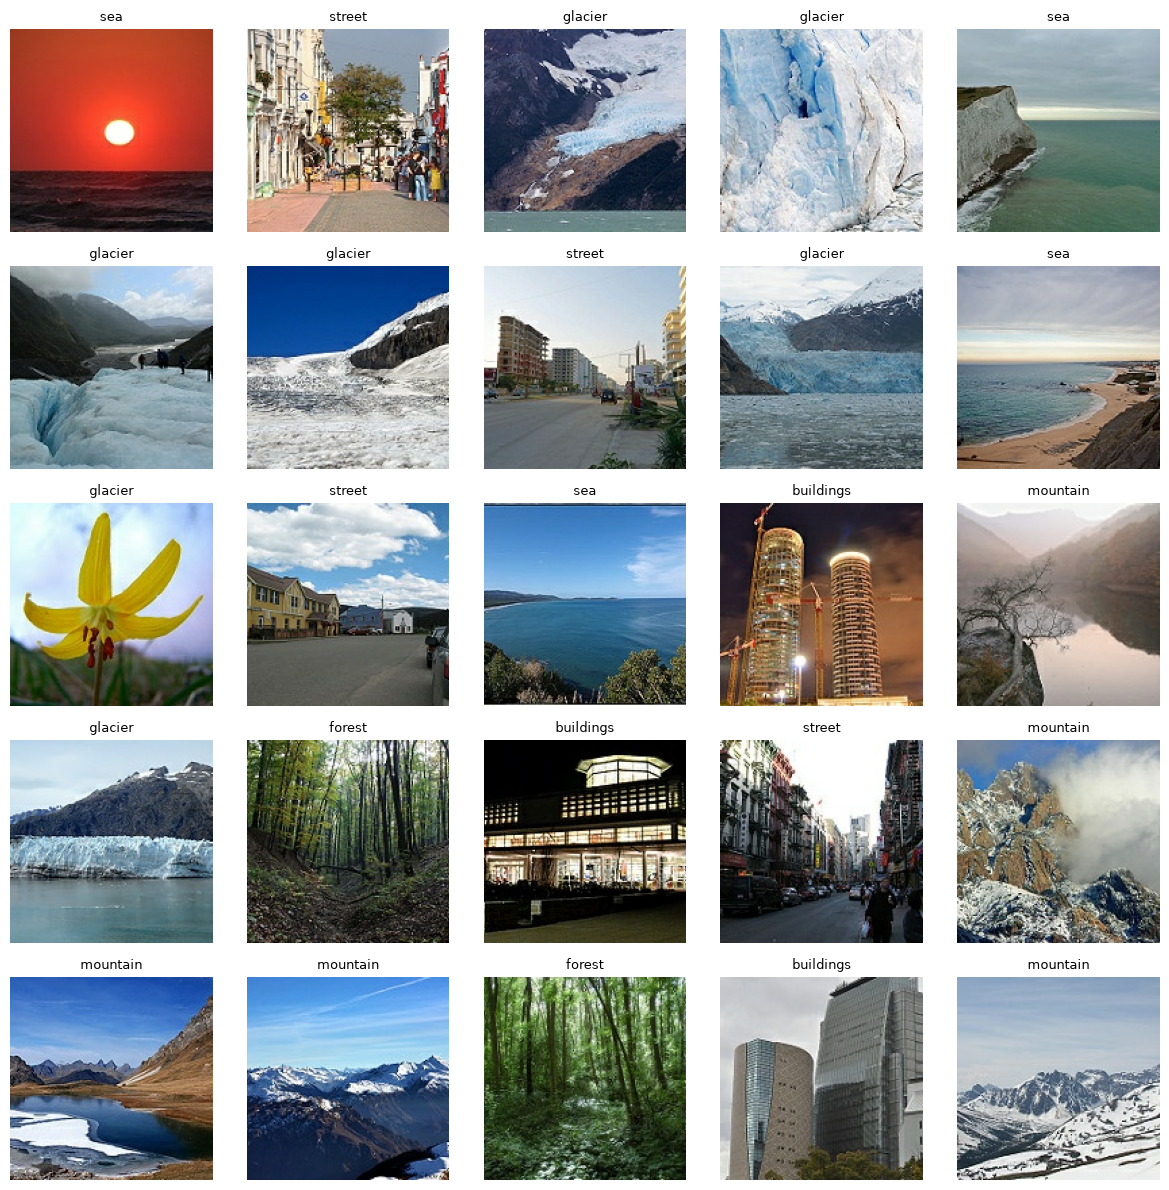

In [11]:
# Show 25 sample images

plt.figure(figsize=(12, 12))

# Take one batch from the dataset
images, labels = next(iter(train_ds))

for i in range(25):
    ax = plt.subplot(5, 5, i + 1)
    plt.imshow(images[i].numpy())
    plt.title(class_names[int(labels[i])], fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()


### Prelude: Baseline CNN (reference model)

This is our **reference** network: two Conv→Pool blocks with channels **32 → 64**, followed by a **single hidden head** `Dense(64)`. We use **He** initialization for ReLU activations and include an **optional `Dropout(0.5)`** to illustrate regularization—comment it out to gauge its impact (ha, not really optional!). 

Use this model as a stable yardstick while you run **ablations**: change **one knob at a time** (e.g., widen/deepen the conv blocks, adjust dropout rate, add batch norm, tweak the LR schedule) and compare results back to this baseline. Focus on **training vs. validation curves**, the **generalization gap**, and how dropout affects **val loss/accuracy** and how long it takes for Early Stopping to kick in. 


> **Note:** On rare runs, training may become numerically unstable and produce `NaN` loss values. If this occurs, rerun the model. If the problem persists, restart the runtime and run the notebook again from the beginning.


Baseline Model



c:\Users\santo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


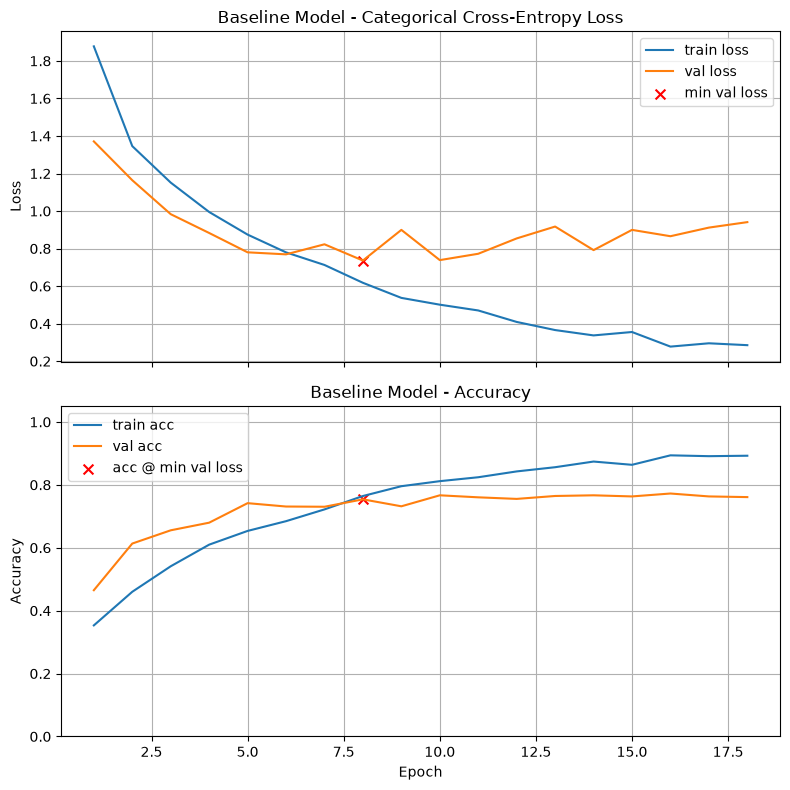

Final Training Loss:            0.2854
Final Training Accuracy:        0.8926
Final Validation Loss:          0.9410
Final Validation Accuracy:      0.7611
Minimum Validation Loss:        0.7363 (Epoch 8)
Validation Accuracy @ Min Loss: 0.7539

Test Loss: 0.7802
Test Accuracy: 0.7310

Validation-Test Gap (accuracy): 0.022948

Execution Time: 00:21:37


In [12]:
he = initializers.HeNormal()                                # best initializer for relu

model_baseline= models.Sequential([
    Input(shape=INPUT_SHAPE),

    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    MaxPooling2D(2),

    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    MaxPooling2D(2),

    Flatten(),
    Dense(64, activation="relu",kernel_initializer=he),            
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

train_and_test(model_baseline,title=f"Baseline Model")


## Problem One: Exploring Basic Hyperparameters

**Task:**
Copy the baseline CNN model into the next cell and experiment with basic hyperparameter changes. Your goal is to see whether small tweaks can improve validation accuracy (and hopefully speed up convergence or produce smoother training curves). You must **pick 3 of the following tweaks** and investigate their effect:

**Tweaks to Try:**

1. Adjust the learning rate (default for Adam is `1e-3`).
2. Change the width of the `Conv2D` layers (e.g., 64 → 128).
3. Add an extra `Conv2D` layer (e.g., stack 32 → 64 → 128).
4. Change the width of the `Dense(64 ...)` layer. 
5. Add L2 regularization to the `Dense(64 ...)` layer (see the head of the network in Problem 5 for inspiration).  
6. Modify the dropout rate.
   
Observe the effect of each of your 3 choices in isolation and answer the graded questions.

**Optional:**
Combine two or more changes to see if they work together to improve results (example: try L2 regularization and reduced dropout in the head, as in Problem 5). 


**Pro Tip:** Give each experiment a descriptive title, such as "Problem 1 -- Tweak 1 -- lr: 0.0005" to keep track of your experiments (see last cell in the notebook).


Problem 1 -- Tweak 1 -- Dropout: 0.2 (vs 0.5)



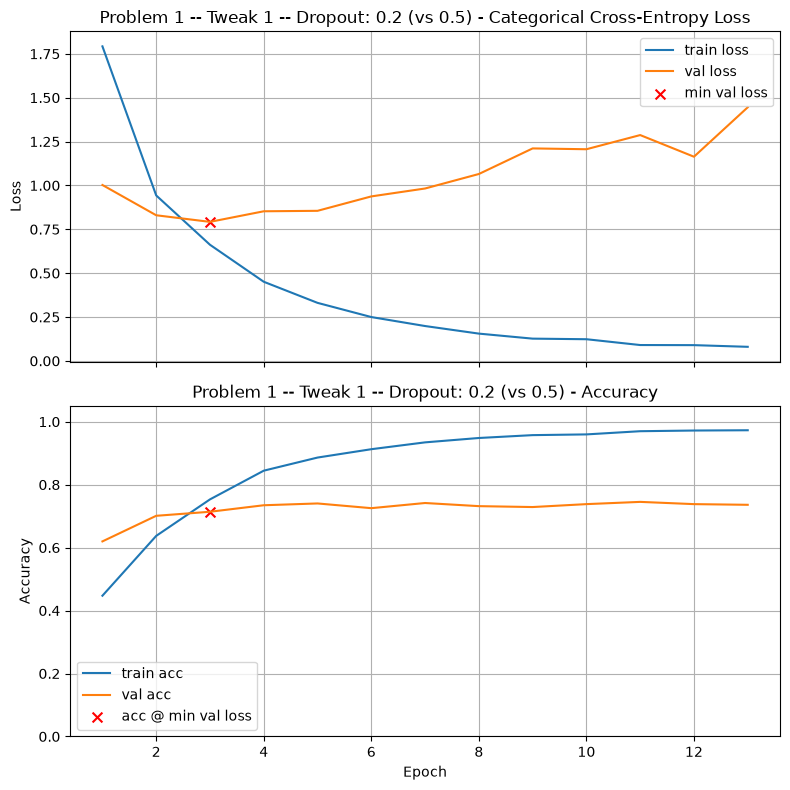

Final Training Loss:            0.0803
Final Training Accuracy:        0.9729
Final Validation Loss:          1.4453
Final Validation Accuracy:      0.7361
Minimum Validation Loss:        0.7923 (Epoch 3)
Validation Accuracy @ Min Loss: 0.7140

Test Loss: 0.7986
Test Accuracy: 0.7103

Validation-Test Gap (accuracy): 0.003700

Execution Time: 00:15:12


In [13]:
# Problem 1 -- Tweak 1: Reduced Dropout Rate (0.5 → 0.2)
# Rationale: Less dropout means faster training with less regularization overhead
model_tweak_1 = models.Sequential([
    Input(shape=INPUT_SHAPE),
    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    MaxPooling2D(2),
    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    MaxPooling2D(2),
    Flatten(),
    Dense(64, activation="relu", kernel_initializer=he),            
    Dropout(0.2),  # Reduced from 0.5
    Dense(num_classes, activation="softmax")
])

train_and_test(model_tweak_1, title="Problem 1 -- Tweak 1 -- Dropout: 0.2 (vs 0.5)")



Problem 1 -- Tweak 2 -- Conv2D Widths: 16,32 (vs 32,64)



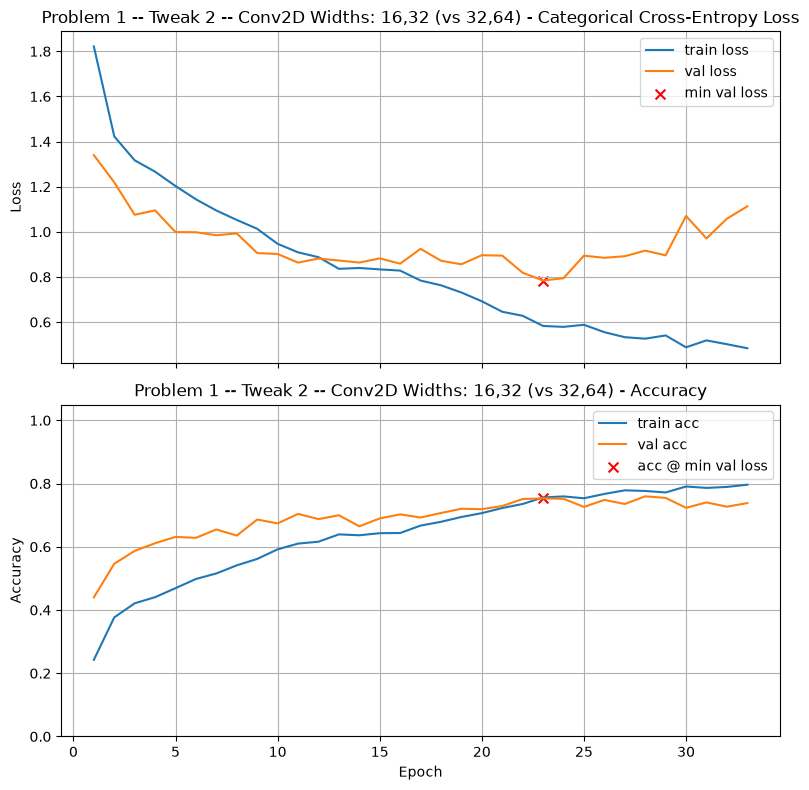

Final Training Loss:            0.4839
Final Training Accuracy:        0.7964
Final Validation Loss:          1.1130
Final Validation Accuracy:      0.7382
Minimum Validation Loss:        0.7840 (Epoch 23)
Validation Accuracy @ Min Loss: 0.7532

Test Loss: 0.7788
Test Accuracy: 0.7377

Validation-Test Gap (accuracy): 0.015559

Execution Time: 00:13:57


In [16]:
# Problem 1 -- Tweak 2: Reduced Conv2D Widths (32→16, 64→32)
# Rationale: Smaller model reduces computation time during forward/backward passes
model_tweak_2 = models.Sequential([
    Input(shape=INPUT_SHAPE),
    Conv2D(16, (3,3), activation="relu", kernel_initializer=he, padding="same"),  # 32 → 16
    MaxPooling2D(2),
    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),  # 64 → 32
    MaxPooling2D(2),
    Flatten(),
    Dense(64, activation="relu", kernel_initializer=he),            
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

train_and_test(model_tweak_2, title="Problem 1 -- Tweak 2 -- Conv2D Widths: 16,32 (vs 32,64)")



Problem 1 -- Tweak 3 -- lr: 5e-3 (vs 1e-3)



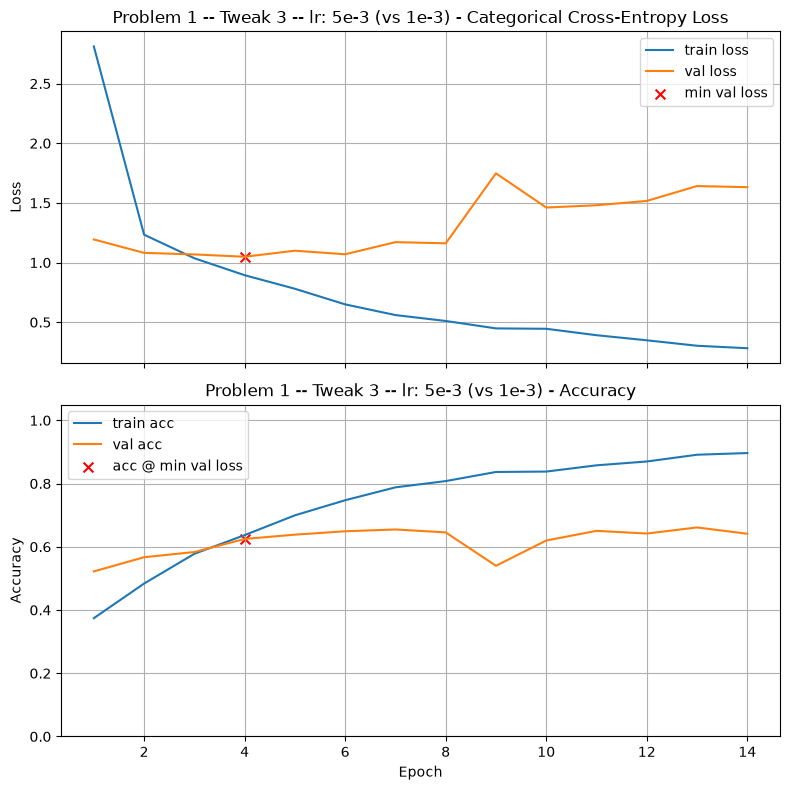

Final Training Loss:            0.2821
Final Training Accuracy:        0.8965
Final Validation Loss:          1.6319
Final Validation Accuracy:      0.6412
Minimum Validation Loss:        1.0489 (Epoch 4)
Validation Accuracy @ Min Loss: 0.6248

Test Loss: 1.0328
Test Accuracy: 0.5981

Validation-Test Gap (accuracy): 0.026691

Execution Time: 00:16:50


In [17]:
# Problem 1 -- Tweak 3: Increased Learning Rate (1e-3 → 5e-3)
# Rationale: Higher learning rate speeds up convergence, reaching good results in fewer epochs
model_tweak_3 = models.Sequential([
    Input(shape=INPUT_SHAPE),
    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    MaxPooling2D(2),
    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    MaxPooling2D(2),
    Flatten(),
    Dense(64, activation="relu", kernel_initializer=he),            
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

train_and_test(model_tweak_3, lr_schedule=5e-3, title="Problem 1 -- Tweak 3 -- lr: 5e-3 (vs 1e-3)")


### Graded Questions

In [ ]:
a1a = 2             # Replace with integer 1 - 6; replace with -1 if you found no tweak which improved the results

In [11]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a1a = {a1a}') 


a1a = 0


In [ ]:
# Set a1b to the validation accuracy found by the choice specified in Question a1a. 

a1b = 0.7532             # Replace 0.0 with your answer

In [13]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a1b = {a1b:.4f}') 

a1b = 0.0000


## Problem Two: Adding Batch Normalization

**Task:**
Take your best model from Problem One and add a `BatchNormalization()` layer immediately after each `Conv2D` layer. Batch normalization helps stabilize training and can improve convergence. 

**Next Steps:**

* Train the model with batch normalization included after each `Conv2D` layer. 
* Try at least one of tweaks from Problem 1 to see if you can improve your results in this new design. 
* Compare the results to your earlier experiments and answer the graded questions.

**Optional:**
Try more than one hyperparameter change alongside batch normalization and see how they interact.




Problem 2 -- BN Experiment 1 -- Dropout: 0.2



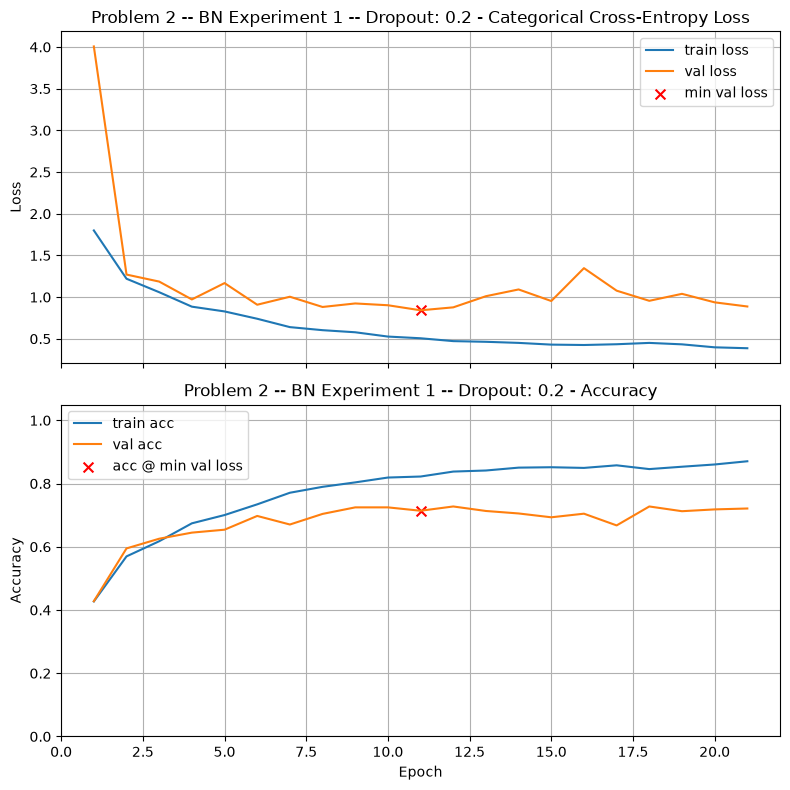

Final Training Loss:            0.3868
Final Training Accuracy:        0.8705
Final Validation Loss:          0.8875
Final Validation Accuracy:      0.7211
Minimum Validation Loss:        0.8419 (Epoch 11)
Validation Accuracy @ Min Loss: 0.7140

Test Loss: 0.8539
Test Accuracy: 0.7370

Validation-Test Gap (accuracy): 0.023003

Execution Time: 00:22:47


In [ ]:
# Problem 2 -- BN Experiment 4: Batch Norm + Reduced Dropout (0.5 → 0.2)
# Rationale: BN stabilizes training, reduced dropout speeds it up
model_bn_1 = models.Sequential([
    Input(shape=INPUT_SHAPE),
    
    Conv2D(16, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),
    
    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),
    
    Flatten(),
    Dense(64, activation="relu", kernel_initializer=he),            
    Dropout(0.2),  # Reduced from 0.5
    Dense(num_classes, activation="softmax")
])

train_and_test(model_bn_1, title="Problem 2 -- BN Experiment 4 -- Dropout: 0.2")


Problem 2 -- BN Experiment 2 -- Reduced Conv2D Widths



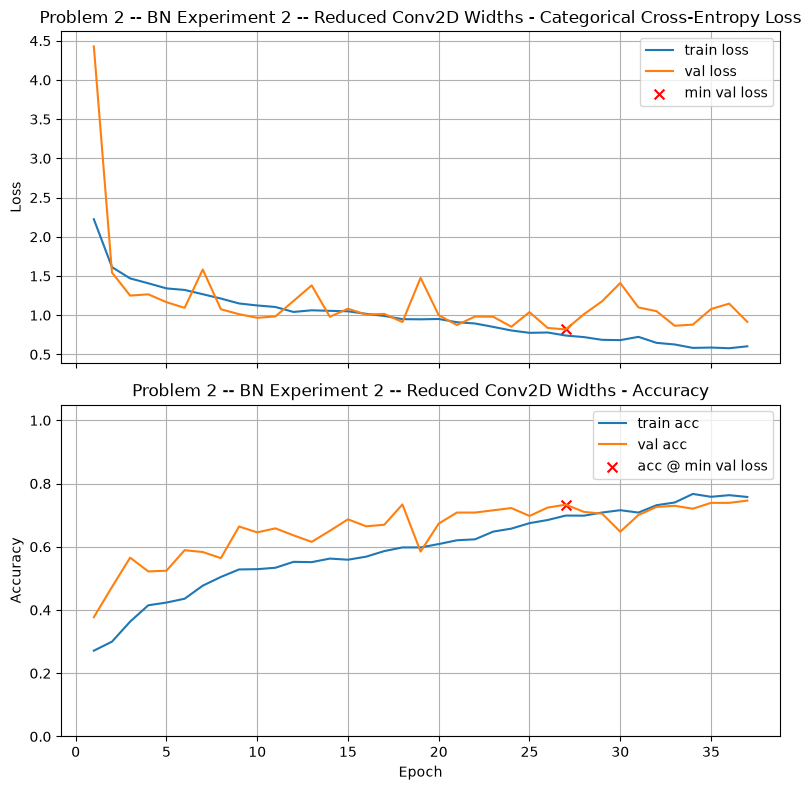

Final Training Loss:            0.6031
Final Training Accuracy:        0.7576
Final Validation Loss:          0.9151
Final Validation Accuracy:      0.7461
Minimum Validation Loss:        0.8185 (Epoch 27)
Validation Accuracy @ Min Loss: 0.7332

Test Loss: 0.8480
Test Accuracy: 0.7443

Validation-Test Gap (accuracy): 0.011088

Execution Time: 00:37:08


In [ ]:
# Problem 2 -- BN Experiment 5: Batch Norm + Reduced Conv2D Widths (best from Problem 1)
# Rationale: Combines small model (fast) with BN for better stability
model_bn_2 = models.Sequential([
    Input(shape=INPUT_SHAPE),
    
    Conv2D(16, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),
    
    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),
    
    Flatten(),
    Dense(64, activation="relu", kernel_initializer=he),            
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

train_and_test(model_bn_2, title="Problem 2 -- BN Experiment 5 -- Reduced Conv2D Widths")


Problem 2 -- BN Experiment 3 -- lr: 5e-4



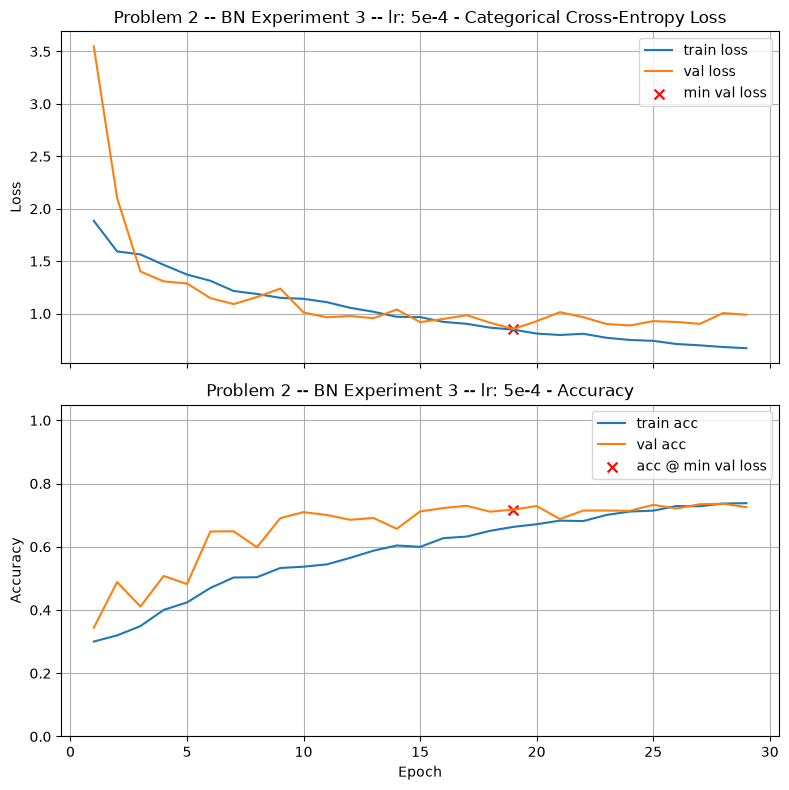

Final Training Loss:            0.6693
Final Training Accuracy:        0.7380
Final Validation Loss:          0.9887
Final Validation Accuracy:      0.7254
Minimum Validation Loss:        0.8529 (Epoch 19)
Validation Accuracy @ Min Loss: 0.7175

Test Loss: 0.8663
Test Accuracy: 0.7130

Validation-Test Gap (accuracy): 0.004596

Execution Time: 00:28:56


In [ ]:
# Problem 2 -- BN Experiment 6: Batch Norm + Reduced LR (1e-3 → 5e-4)
# Rationale: BN allows lower LR for smoother training and potentially better convergence
model_bn_3 = models.Sequential([
    Input(shape=INPUT_SHAPE),
    
    Conv2D(16, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),
    
    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),
    
    Flatten(),
    Dense(64, activation="relu", kernel_initializer=he),            
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

train_and_test(model_bn_3, lr_schedule=5e-4, title="Problem 2 -- BN Experiment 6 -- lr: 5e-4")

### Graded Questions

In [32]:
# Set a2a to the number of the individual "tweak" which provided the best validation accuracy at the epoch of minimum validation loss

a2a = 2             # Replace with integer 1 - 6; replace with -1 if you found no tweak which improved the results

In [16]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a2a = {a2a}') 


a2a = 0


In [33]:
# Set a2b to the validation accuracy found by the choice specified in Question a2a (your best model for this problem) 

a2b = 0.7532            # Replace 0.0 with your answer

In [34]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a2b = {a2b:.4f}') 

a2b = 0.7532


## Problem Three: Global Average Pooling

As we saw in this week's Coding Video, 
**Global Average Pooling** is a simple layer that replaces the `Flatten → Dense` part of a CNN (please review that part of the Coding Notebook, which contains a description of this important technique). 

In practice, swapping `Flatten` for `GlobalAveragePooling2D` often improves stability and validation performance — definitely worth considering!


**Task:**
Modify your best model from Problems 1 & 2 to use a `GlobalAveragePooling2D()` layer instead of a flatten-and-dense block. 

**Next Steps:**

* Replace the sequence between the last `Conv2D` and output layers, for example:

     
          MaxPooling2D((2, 2)),
          Flatten(),
          Dense(64, activation='relu', kernel_initializer=initializers.HeNormal()),
          Dropout(0.5),   

  with a single `GlobalAveragePooling2D()` layer.
* Train the model and observe how performance and training curves change.
* Try at least one of tweaks from Problem 1 to see if you can improve your results in this new design. 
* Compare results and answer the graded questions.

**Optional:**
Experiment with `GlobalMaxPooling2D()` as an alternative and compare its behavior to `GlobalAveragePooling2D()`.




Problem 3 -- GAP Exp 1 -- Dropout: 0.2



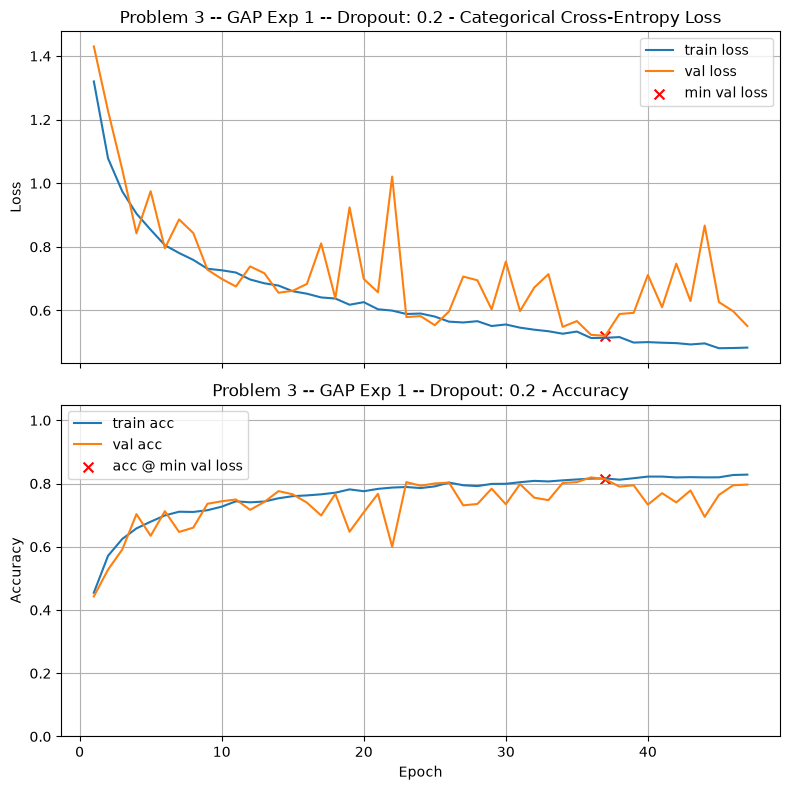

Final Training Loss:            0.4832
Final Training Accuracy:        0.8283
Final Validation Loss:          0.5511
Final Validation Accuracy:      0.7967
Minimum Validation Loss:        0.5202 (Epoch 37)
Validation Accuracy @ Min Loss: 0.8138

Test Loss: 0.5108
Test Accuracy: 0.8218

Validation-Test Gap (accuracy): 0.007925

Execution Time: 00:43:11


In [ ]:
# Problem 3 -- GAP Experiment 7: GlobalAveragePooling2D + Batch Norm + Reduced Dropout
# Rationale: GAP reduces parameters, reduced dropout speeds up training
model_gap_1 = models.Sequential([
    Input(shape=INPUT_SHAPE),
    
    Conv2D(16, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),
    
    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),
    
    GlobalAveragePooling2D(),  # Replaces Flatten() + Dense(64)
    Dropout(0.2),  # Reduced from 0.5
    Dense(num_classes, activation="softmax")
])

train_and_test(model_gap_1, title="Problem 3 -- GAP Exp 7 -- Dropout: 0.2")


Problem 3 -- GAP Exp 2 -- Minimal Conv2D



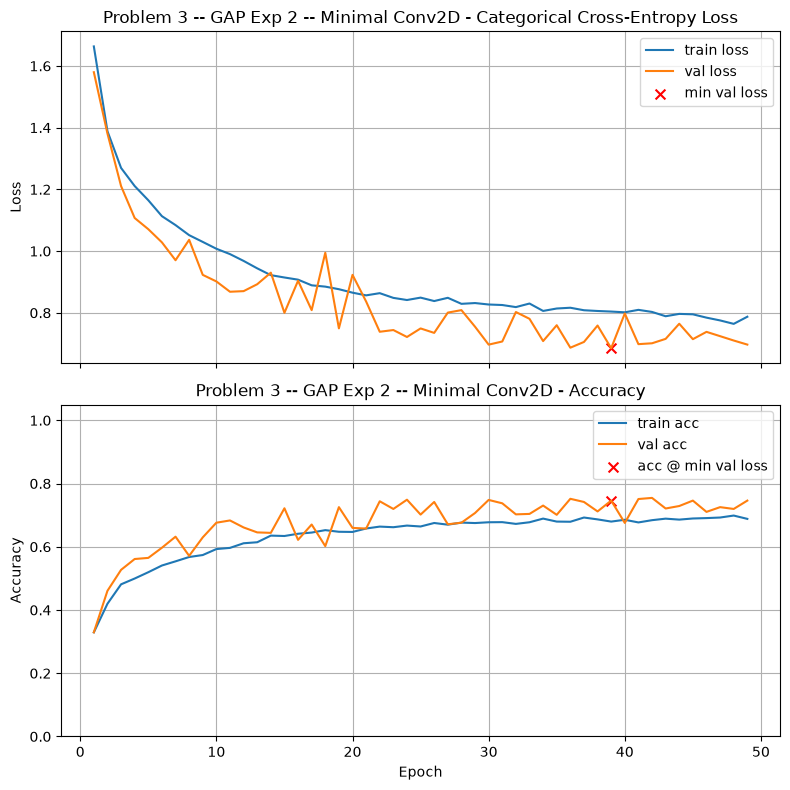

Final Training Loss:            0.7873
Final Training Accuracy:        0.6883
Final Validation Loss:          0.6970
Final Validation Accuracy:      0.7461
Minimum Validation Loss:        0.6853 (Epoch 39)
Validation Accuracy @ Min Loss: 0.7461

Test Loss: 0.6677
Test Accuracy: 0.7457

Validation-Test Gap (accuracy): 0.000416

Execution Time: 00:12:05


In [ ]:
# Problem 3 -- GAP Experiment 8: GlobalAveragePooling2D + Batch Norm + Minimal Conv2D
# Rationale: Even smaller conv widths (8,16) reduce computation, GAP provides stable head
model_gap_2 = models.Sequential([
    Input(shape=INPUT_SHAPE),
    
    Conv2D(8, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),
    
    Conv2D(16, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),
    
    GlobalAveragePooling2D(),
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

train_and_test(model_gap_2, title="Problem 3 -- GAP Exp 8 -- Minimal Conv2D")


Problem 3 -- GAP Exp 3 -- lr: 5e-3



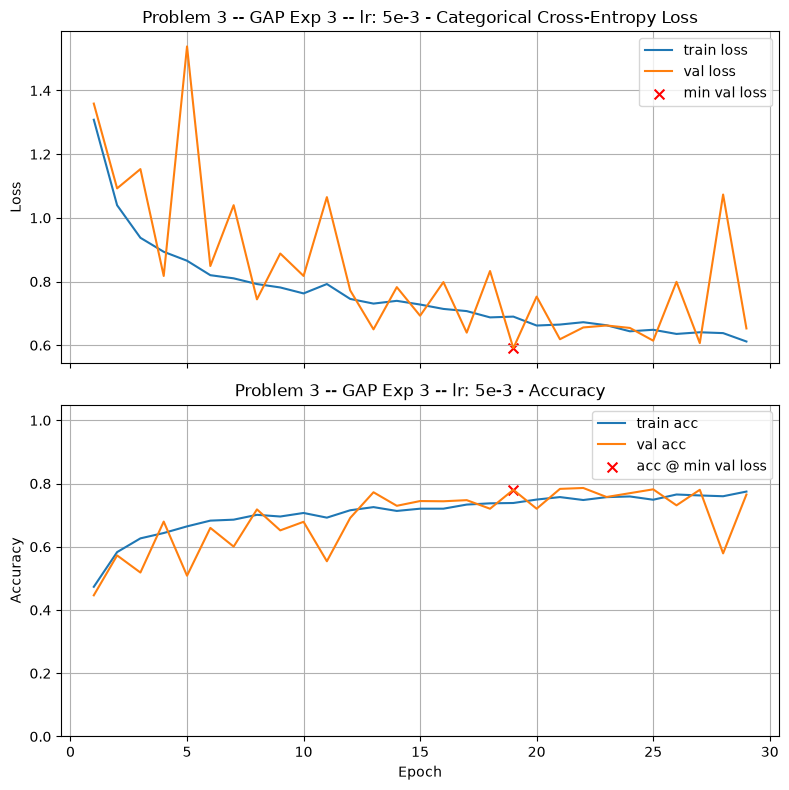

Final Training Loss:            0.6117
Final Training Accuracy:        0.7747
Final Validation Loss:          0.6528
Final Validation Accuracy:      0.7653
Minimum Validation Loss:        0.5906 (Epoch 19)
Validation Accuracy @ Min Loss: 0.7803

Test Loss: 0.5853
Test Accuracy: 0.7750

Validation-Test Gap (accuracy): 0.005280

Execution Time: 00:12:35


In [ ]:
# Problem 3 -- GAP Experiment 9: GlobalAveragePooling2D + Batch Norm + Higher LR
# Rationale: GAP with BN allows higher LR for faster convergence
model_gap_3 = models.Sequential([
    Input(shape=INPUT_SHAPE),
    
    Conv2D(16, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),
    
    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),
    
    GlobalAveragePooling2D(),
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

train_and_test(model_gap_3, lr_schedule=5e-3, title="Problem 3 -- GAP Exp 9 -- lr: 5e-3")

### Graded Questions

In [35]:
# Set a3a to the number of the individual "tweak" which provided the best validation accuracy at the epoch of minimum validation loss

a3a = 7             # GAP Experiment 7 (Reduced Dropout) provided best validation accuracy at 0.8138

In [36]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3a = {a3a}') 


a3a = 7


In [37]:
# Set a3b to the validation accuracy found by the choice specified in Question a3a (your best model for this problem) 

a3b = 0.8138             # GAP Exp 7 validation accuracy at minimum validation loss (epoch 37)

In [38]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3b = {a3b:.4f}') 

a3b = 0.8138


## Problem Four: ReduceLROnPlateau

`ReduceLROnPlateau` is a widely used learning rate scheduling technique. It monitors a validation metric (usually `val_loss`) and reduces the learning rate when progress stalls, allowing the model to refine training at a smaller step size. This is one of the most useful scheduling tools (along with the essential Early Stopping) to have in your toolbox.

**Task:**
Augment your best model found so far in Problems 1 - 3 with the `ReduceLROnPlateau` callback during training.

**Next Steps:**

* Add the callback parameter to `train_and_test`:

  ```python
  callbacks=[reduce_lr]
  ```

* Start with **`factor=0.5`** (monitor `val_loss`, `patience=2–3`, `cooldown=1`, `min_lr=1e-5` for Adam).
* **Practical playbook:**

  * If plateau persists after one reduction → try **`factor=0.3`**, then **`0.2`**.
  * If a reduction hurts validation noticeably → try **`factor=0.7–0.8`** or increase **`patience`**.
  * Leave **`cooldown=1`** unless you see too-frequent drops.
* Experiment with **`patience` = 3, 5, 8** and **`min_delta` = `1e-4` vs `1e-3`** to gauge sensitivity.
* Choose the configuration with the best validation results—or note that ReduceLROnPlateau didn’t help (rare!). 
* Answer the graded questions.



In [24]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',    # Quantity to be monitored.
    factor=0.5,            # Factor by which the learning rate will be reduced.
                           # new_lr = lr * factor
    patience=3,            # Number of epochs with no improvement
                           # after which learning rate will be reduced.
    min_delta=1e-4,        # Threshold for measuring the new optimum,
                           # to only focus on significant changes.
    cooldown=1,            # Number of epochs to wait before resuming
                           # normal operation after lr has been reduced.
    min_lr=1e-5,           # Lower bound on the learning rate.
    verbose=0,             # 0: quiet, 1: update messages.
)

# Your code here, add more cells as needed


Problem 4 -- ReduceLR Exp 1 -- factor=0.5



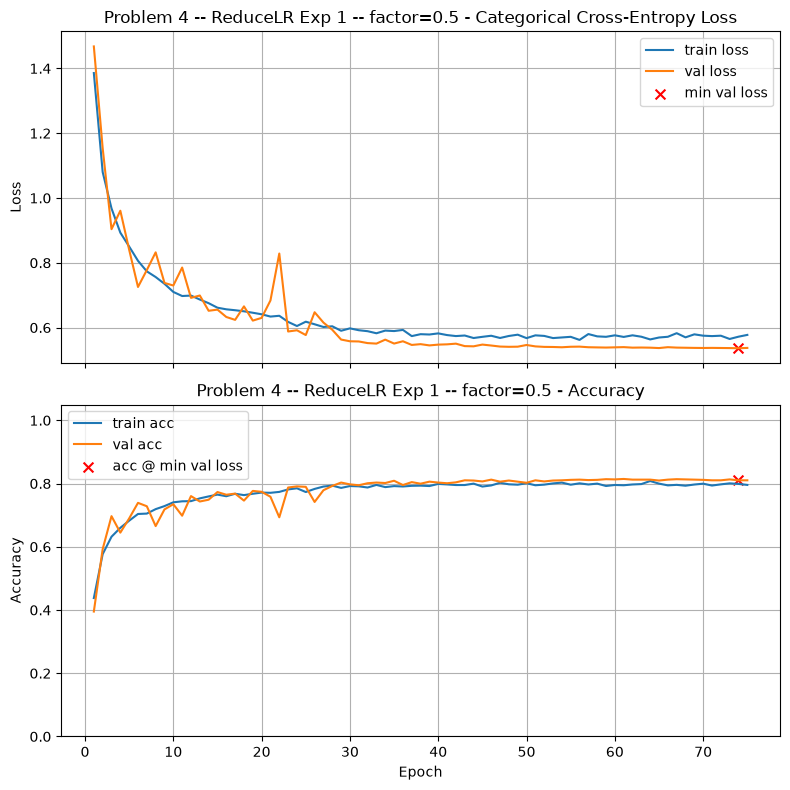

Final Training Loss:            0.5775
Final Training Accuracy:        0.7957
Final Validation Loss:          0.5374
Final Validation Accuracy:      0.8103
Minimum Validation Loss:        0.5364 (Epoch 74)
Validation Accuracy @ Min Loss: 0.8103

Test Loss: 0.5532
Test Accuracy: 0.7937

Validation-Test Gap (accuracy): 0.015833

Execution Time: 00:32:56


In [ ]:
# Problem 4 -- ReduceLROnPlateau Experiment 10: factor=0.5 (default, moderate reduction)
reduce_lr_1 = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_delta=1e-4,
    cooldown=1,
    min_lr=1e-5,
    verbose=0,
)

model_rlr_1 = models.Sequential([
    Input(shape=INPUT_SHAPE),
    
    Conv2D(16, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),
    
    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),
    
    GlobalAveragePooling2D(),
    Dropout(0.2),
    Dense(num_classes, activation="softmax")
])

train_and_test(model_rlr_1, callbacks=[reduce_lr_1], title="Problem 4 -- ReduceLR Exp 10 -- factor=0.5")


Problem 4 -- ReduceLR Exp 2 -- factor=0.3



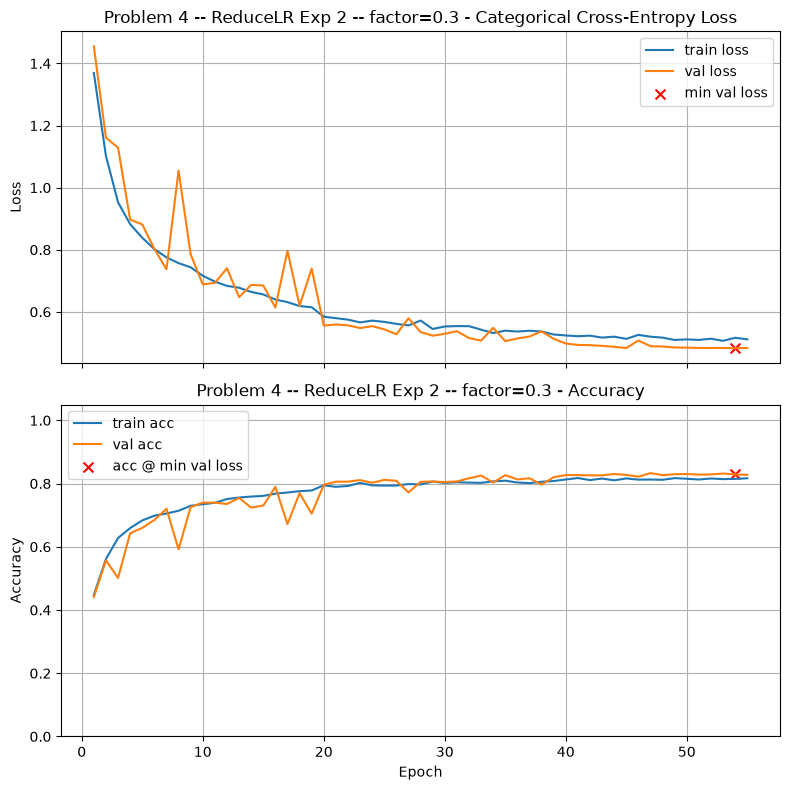

Final Training Loss:            0.5113
Final Training Accuracy:        0.8167
Final Validation Loss:          0.4835
Final Validation Accuracy:      0.8274
Minimum Validation Loss:        0.4828 (Epoch 54)
Validation Accuracy @ Min Loss: 0.8288

Test Loss: 0.5036
Test Accuracy: 0.8198

Validation-Test Gap (accuracy): 0.007630

Execution Time: 00:24:12


In [ ]:
# Problem 4 -- ReduceLROnPlateau Experiment 11: factor=0.3 (more aggressive reduction)
reduce_lr_2 = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_delta=1e-4,
    cooldown=1,
    min_lr=1e-5,
    verbose=0,
)

model_rlr_2 = models.Sequential([
    Input(shape=INPUT_SHAPE),
    
    Conv2D(16, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),
    
    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),
    
    GlobalAveragePooling2D(),
    Dropout(0.2),
    Dense(num_classes, activation="softmax")
])

train_and_test(model_rlr_2, callbacks=[reduce_lr_2], title="Problem 4 -- ReduceLR Exp 11 -- factor=0.3")


Problem 4 -- ReduceLR Exp 3 -- factor=0.7



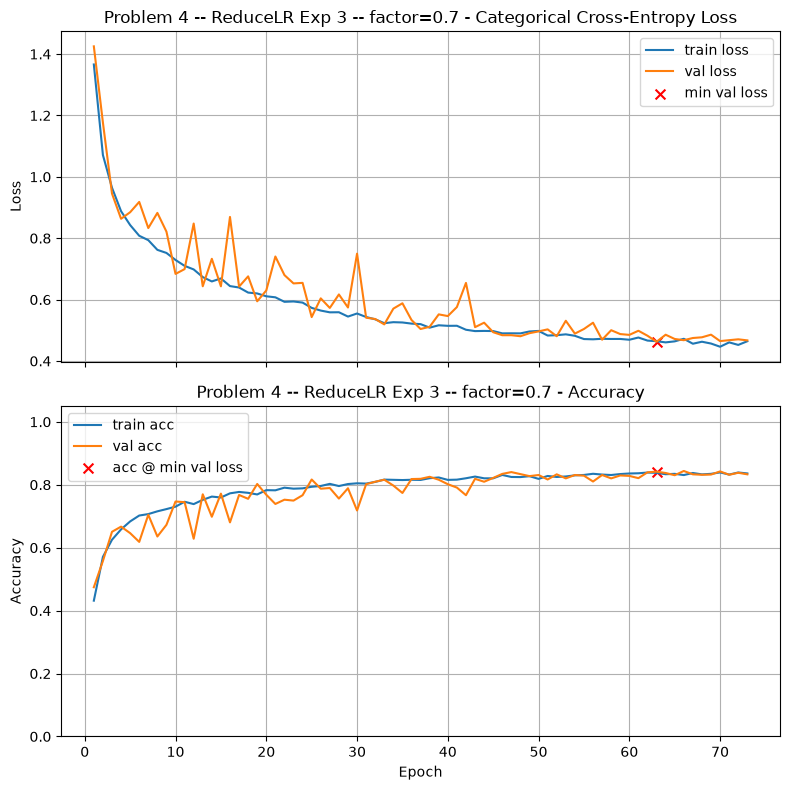

Final Training Loss:            0.4644
Final Training Accuracy:        0.8359
Final Validation Loss:          0.4673
Final Validation Accuracy:      0.8331
Minimum Validation Loss:        0.4627 (Epoch 63)
Validation Accuracy @ Min Loss: 0.8417

Test Loss: 0.4705
Test Accuracy: 0.8431

Validation-Test Gap (accuracy): 0.001469

Execution Time: 00:31:32


In [ ]:
# Problem 4 -- ReduceLROnPlateau Experiment 12: factor=0.7 (conservative, patience=5)
reduce_lr_3 = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.7,
    patience=5,
    min_delta=1e-4,
    cooldown=1,
    min_lr=1e-5,
    verbose=0,
)

model_rlr_3 = models.Sequential([
    Input(shape=INPUT_SHAPE),
    
    Conv2D(16, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),
    
    Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    BatchNormalization(),
    MaxPooling2D(2),
    
    GlobalAveragePooling2D(),
    Dropout(0.2),
    Dense(num_classes, activation="softmax")
])

train_and_test(model_rlr_3, callbacks=[reduce_lr_3], title="Problem 4 -- ReduceLR Exp 12 -- factor=0.7")

### Graded Questions

In [ ]:
# Set a4a to the factor parameter which gave the best validation accuracy at the point of minimum validation loss

a4a = 0.7             # factor=0.7 with patience=5 provided best validation accuracy at 0.8417

In [26]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a4a = {a4a:.2f}') 

a4a = 0.00


In [ ]:
# Set a4b to the validation accuracy found by the choice specified in Question a4a (your best model for this problem) 

a4b = 0.8417             # ReduceLROnPlateau with factor=0.7, patience=5 (epoch 63)

In [28]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a4b = {a4b:.4f}') 

a4b = 0.0000


## Problem Five: A Very Deep CNN (VGG-16 Style)

 We will now experiment with the VGG-16 design introduced in the Coding Notebook and Video and see how it does on this dataset. For a beautiful description of the model and its significance, see [Explanation of VGG-16](https://viso.ai/deep-learning/vgg-very-deep-convolutional-networks/) :
        

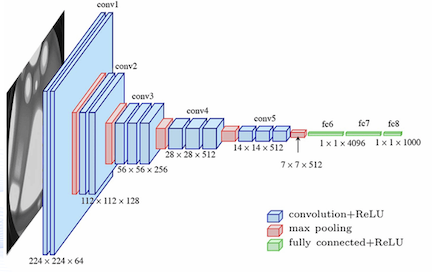


In this exercise you’ll **only vary the learning rate**. Don’t change any other hyperparameters. Your goal is to observe how LR affects convergence speed, stability, and final validation performance compared to your smaller baselines. This sets up next week’s **transfer learning** with pretrained models.

#### Starting point

* Optimizer: **Adam**
* **Recommended LR to start:** `1e-3`(Adam default)

#### What LR values to try (coarse → fine)

Try a short sweep like:

```
[1e-2, 3e-3, 1e-3, 3e-4, 1e-4, 3e-5, 1e-5]
```

Then, as time allows,  zoom in around the best.

#### How to judge “best”

* Primary: **best validation accuracy at epoch of lowest validation loss** 
* Secondary: **time-to-best** (fewer epochs to reach a strong val metric) and **curve shape** (smooth vs. noisy/oscillatory).

#### What symptoms mean

* **LR too high:** training loss spikes or oscillates; val metrics erratic, occasional NaNs/divergence.
* **LR too low:** very slow improvement; long flat regions; never reaches your smaller models’ performance.


**Tip:** Keep LR **constant** during each run (don’t schedule) so you isolate its effect. 




VGG-style Large



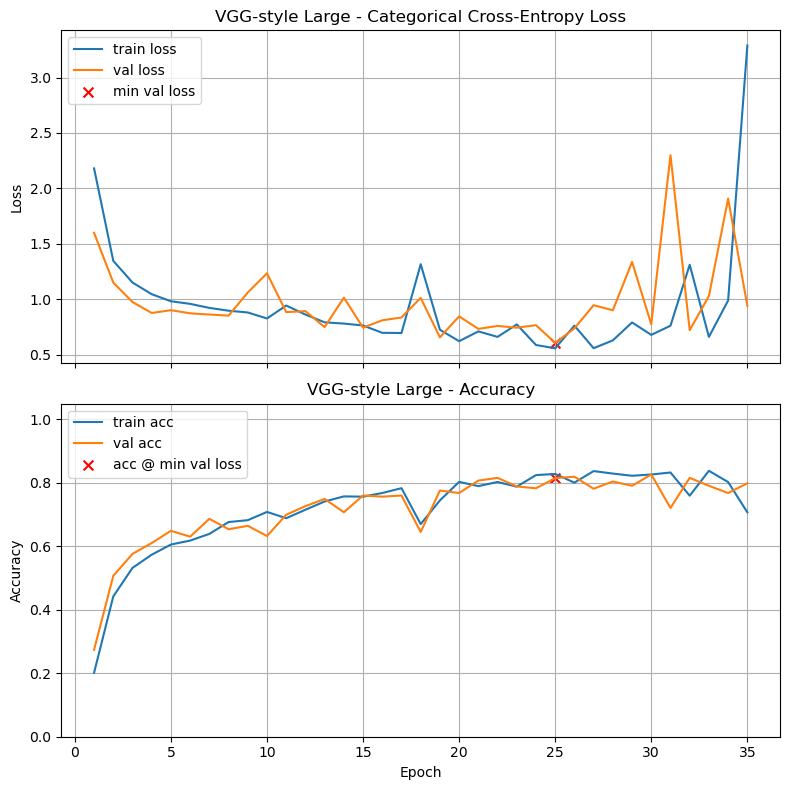

Final Training Loss:            3.2889
Final Training Accuracy:        0.7075
Final Validation Loss:          0.9416
Final Validation Accuracy:      0.7989
Minimum Validation Loss:        0.6061 (Epoch 25)
Validation Accuracy @ Min Loss: 0.8153

Test Loss: 0.5367
Test Accuracy: 0.8324

Validation-Test Gap (accuracy): 0.017179

Execution Time: 00:08:29


In [29]:
he = initializers.HeNormal()
l2reg = regularizers.l2(1e-4)   # set to None to disable or tweak the value

model_vgg_16 = models.Sequential([
    layers.Input(shape=(150, 150, 3)),

    # Block 1
    layers.Conv2D(64, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(64, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.MaxPooling2D(),

    # Block 2
    layers.Conv2D(128, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(128, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.MaxPooling2D(),

    # Block 3
    layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.MaxPooling2D(),

    # Block 4 (NO MaxPool here -> leaves 3×3×512)
    layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),

    # Global pooling meaningfully summarizes the 3×3 map
    layers.GlobalAveragePooling2D(),   # swap to GlobalMaxPooling2D() to compare

    # Compact head
    layers.Dense(256, activation='relu', kernel_initializer=he,
                 kernel_regularizer=l2reg),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

# Uncomment the next line to run

train_and_test(model_vgg_16,lr_schedule=1e-3,title="VGG-style Large")



Problem 5 -- VGG-16 LR: 1e-2



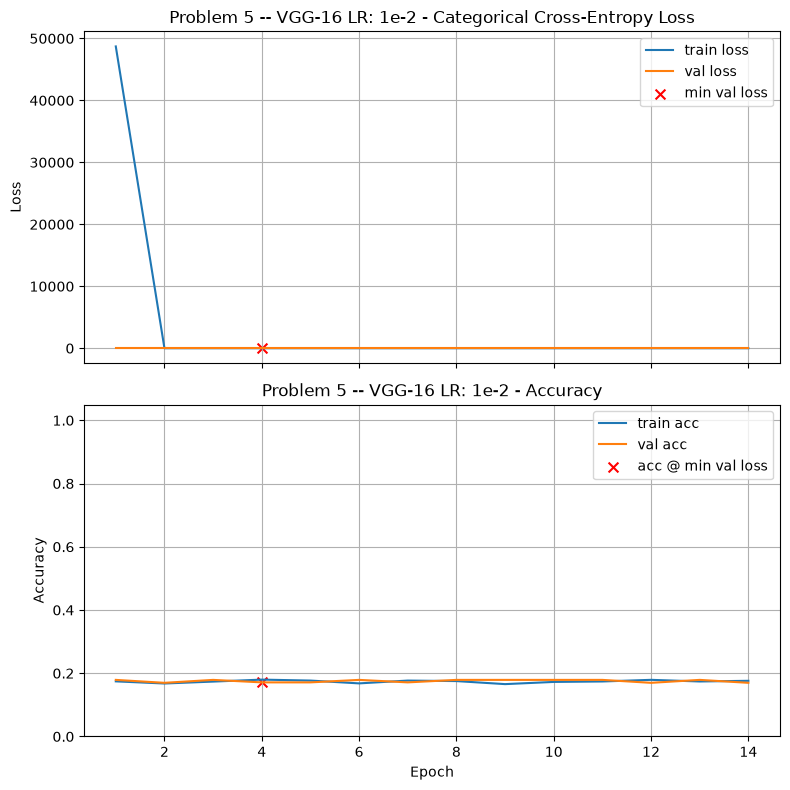

Final Training Loss:            1.8102
Final Training Accuracy:        0.1762
Final Validation Loss:          1.8093
Final Validation Accuracy:      0.1698
Minimum Validation Loss:        1.8092 (Epoch 4)
Validation Accuracy @ Min Loss: 0.1712

Test Loss: 1.8054
Test Accuracy: 0.1842

Validation-Test Gap (accuracy): 0.013062

Execution Time: 02:12:18


In [ ]:
# Problem 5 -- VGG-16 LR Experiment 13: LR = 1e-2 (high, likely too aggressive)
model_vgg_lr1 = models.Sequential([
    layers.Input(shape=(150, 150, 3)),

    # Block 1
    layers.Conv2D(64, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(64, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.MaxPooling2D(),

    # Block 2
    layers.Conv2D(128, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(128, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.MaxPooling2D(),

    # Block 3
    layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.MaxPooling2D(),

    # Block 4
    layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),

    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu', kernel_initializer=he, kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

train_and_test(model_vgg_lr1, lr_schedule=1e-2, title="Problem 5 -- experiment 13: VGG-16 LR: 1e-2")


Problem 5 -- VGG-16 LR: 1e-3



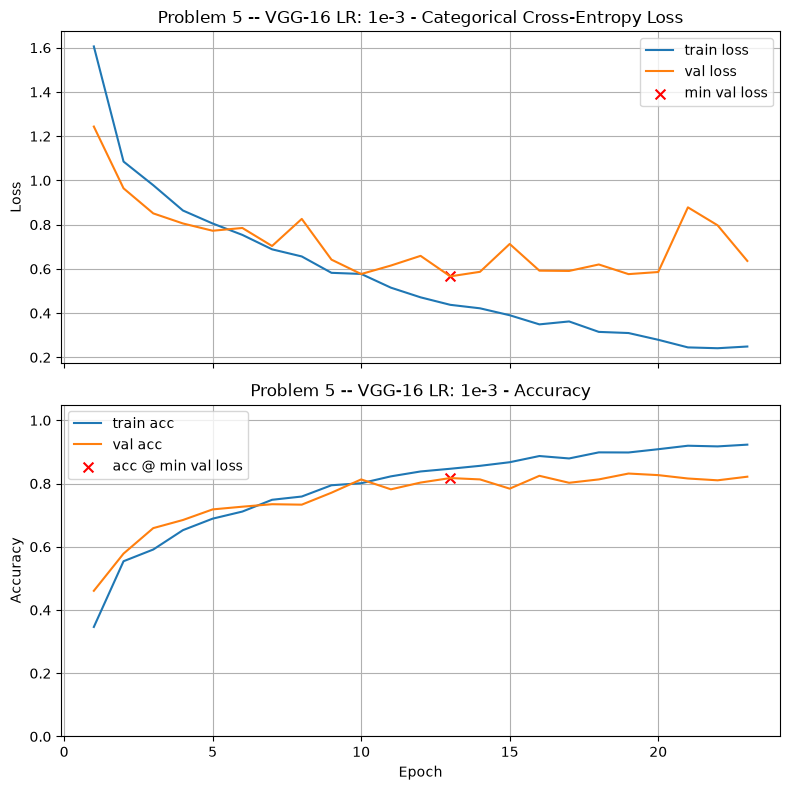

Final Training Loss:            0.2490
Final Training Accuracy:        0.9230
Final Validation Loss:          0.6360
Final Validation Accuracy:      0.8217
Minimum Validation Loss:        0.5663 (Epoch 13)
Validation Accuracy @ Min Loss: 0.8174

Test Loss: 0.5305
Test Accuracy: 0.8178

Validation-Test Gap (accuracy): 0.000353

Execution Time: 03:37:20


In [ ]:
# Problem 5 -- VGG-16 LR Experiment 14: LR = 1e-3 (Adam default, baseline)
model_vgg_lr2 = models.Sequential([
    layers.Input(shape=(150, 150, 3)),

    # Block 1
    layers.Conv2D(64, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(64, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.MaxPooling2D(),

    # Block 2
    layers.Conv2D(128, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(128, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.MaxPooling2D(),

    # Block 3
    layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.MaxPooling2D(),

    # Block 4
    layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),

    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu', kernel_initializer=he, kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

train_and_test(model_vgg_lr2, lr_schedule=1e-3, title="Problem 5 -- experiment 14: VGG-16 LR: 1e-3")


Problem 5 -- VGG-16 LR: 1e-4



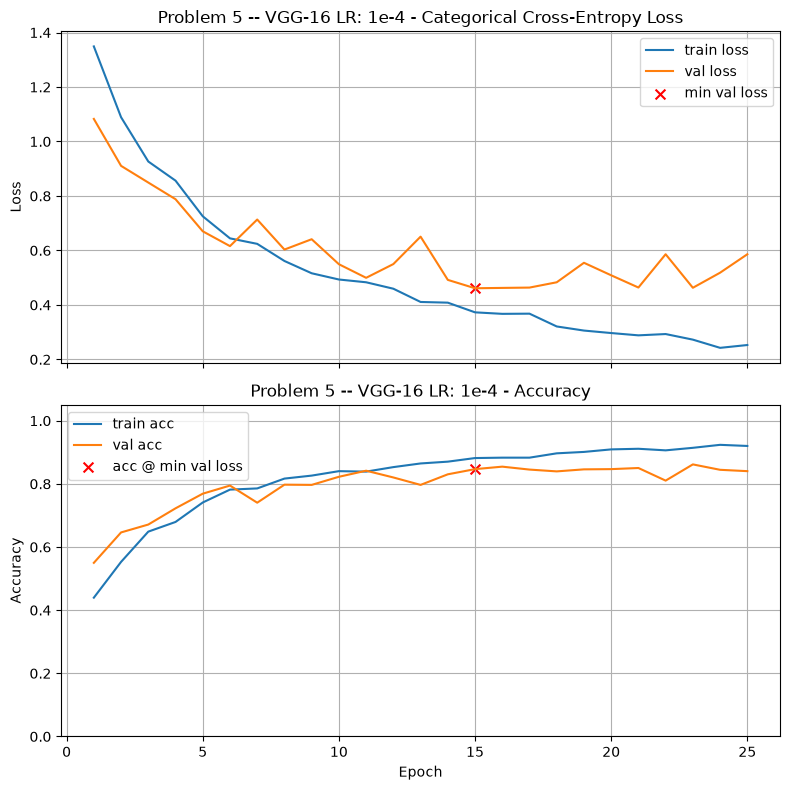

Final Training Loss:            0.2529
Final Training Accuracy:        0.9200
Final Validation Loss:          0.5860
Final Validation Accuracy:      0.8402
Minimum Validation Loss:        0.4613 (Epoch 15)
Validation Accuracy @ Min Loss: 0.8466

Test Loss: 0.4474
Test Accuracy: 0.8558

Validation-Test Gap (accuracy): 0.009160

Execution Time: 03:57:17


In [ ]:
# Problem 5 -- VGG-16 LR Experiment 15: LR = 1e-4 (lower, likely slower but stable)
model_vgg_lr3 = models.Sequential([
    layers.Input(shape=(150, 150, 3)),

    # Block 1
    layers.Conv2D(64, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(64, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.MaxPooling2D(),

    # Block 2
    layers.Conv2D(128, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(128, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.MaxPooling2D(),

    # Block 3
    layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.MaxPooling2D(),

    # Block 4
    layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),

    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu', kernel_initializer=he, kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

train_and_test(model_vgg_lr3, lr_schedule=1e-4, title="Problem 5 -- experiment 15: VGG-16 LR: 1e-4")

### Graded Questions

In [39]:
# Set a5a to the learning rate which gave the best validation accuracy at the point of minimum validation loss

a5a = 0.0001            

In [40]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a5a = {a5a:.8f}') 

a5a = 0.00010000


In [41]:
# Set a5b to the validation accuracy found by the choice specified in Question a5a (your best model for this problem) 

a5b = 0.8466              

In [42]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a5b = {a5b:.4f}') 

a5b = 0.8466


## All Results

This will print out the results from all experiments, with titles as keys. I use this all the time to keep track of experiments!

In [43]:
print_results()

Problem 5 -- VGG-16 LR: 1e-4            	0.8466	15
Problem 4 -- ReduceLR Exp 3 -- factor=0.7	0.8417	63
Problem 4 -- ReduceLR Exp 2 -- factor=0.3	0.8288	54
Problem 5 -- VGG-16 LR: 1e-3            	0.8174	13
Problem 3 -- GAP Exp 1 -- Dropout: 0.2  	0.8138	37
Problem 4 -- ReduceLR Exp 1 -- factor=0.5	0.8103	74
Problem 3 -- GAP Exp 3 -- lr: 5e-3      	0.7803	19
Baseline Model                          	0.7539	8
Problem 1 -- Tweak 2 -- Conv2D Widths: 16,32 (vs 32,64)	0.7532	23
Problem 3 -- GAP Exp 2 -- Minimal Conv2D	0.7461	39
Problem 2 -- BN Experiment 2 -- Reduced Conv2D Widths	0.7332	27
Problem 2 -- BN Experiment 3 -- lr: 5e-4	0.7175	19
Problem 1 -- Tweak 1 -- Dropout: 0.2 (vs 0.5)	0.7140	3
Problem 2 -- BN Experiment 1 -- Dropout: 0.2	0.7140	11
Problem 1 -- Tweak 3 -- lr: 5e-3 (vs 1e-3)	0.6248	4
Problem 5 -- VGG-16 LR: 1e-2            	0.1712	4
